# 01. Matplotlib 객체 지향 방식 기초

## 학습 목표
- Figure와 Axes 객체의 개념 이해
- 객체 지향 방식으로 기본 차트 생성
- 스타일링을 통한 시각적 개선

---

## 1. Figure와 Axes 이해하기

**핵심 개념:**
- `Figure`: 전체 캔버스 (창 또는 페이지)
- `Axes`: 실제 차트가 그려지는 영역 (좌표축 포함)

**왜 객체 지향 방식인가?**
- 여러 차트를 동시에 제어 가능
- 코드 재사용성과 유지보수성 향상
- 복잡한 레이아웃 구성에 유리

In [ ]:
# %conda install matplotlib
# %conda update -n base -c defaults conda
%conda install seaborn

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 한글 폰트 설정 (Windows)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [5]:
# 데이터 로드: 자동차 연비 데이터
mpg = sns.load_dataset("mpg")
mpg.info()
mpg.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    object 
 8   name          398 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 28.1+ KB


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


## 2. 첫 번째 객체 지향 차트: 선 그래프

**비즈니스 질문:** 연도별 평균 연비가 어떻게 변했을까?

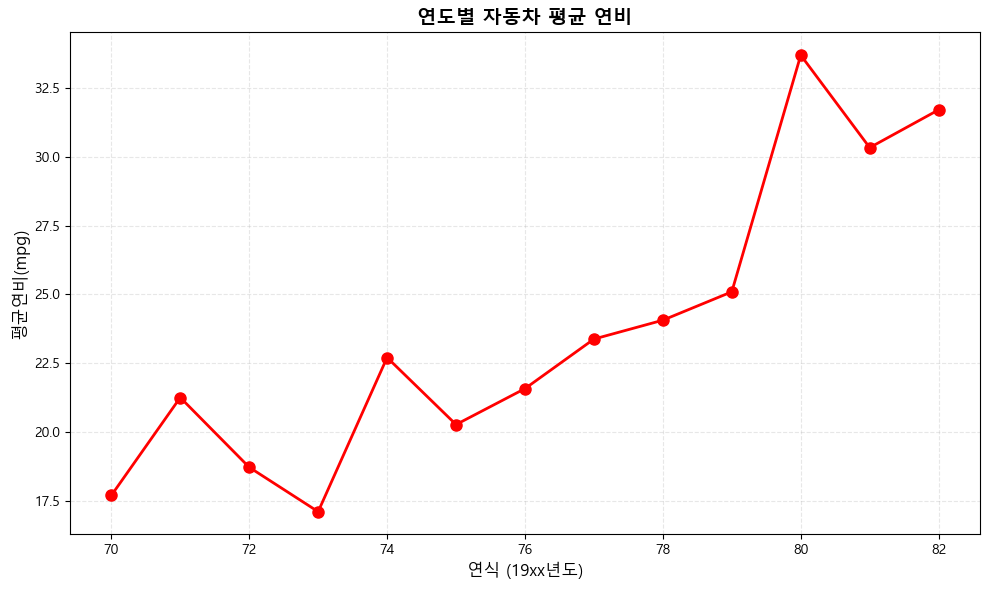

In [21]:
# 연도별 평균 연비 계산
yealy_mpg = mpg.groupby('model_year')['mpg'].mean()

# 객체지향 방식
fig, ax =  plt.subplots(figsize=(10,6))
ax.plot(yealy_mpg.index, yealy_mpg.values,
        marker = 'o', linewidth=2,markersize=8,color='red')
ax.set_xlabel('연식 (19xx년도)',fontsize=12)
ax.set_ylabel('평균연비(mpg)',fontsize=12)
ax.set_title('연도별 자동차 평균 연비', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

# 인사이트: 1970년대 중반부터 연비가 급격히 개선 → 오일쇼크 이후 연비 규제 강화 영향

In [23]:
mpg['origin'].unique()

array(['usa', 'japan', 'europe'], dtype=object)

## 3. 막대 차트: 범주형 비교

**비즈니스 질문:** 어느 제조국의 자동차가 연비가 좋을까?

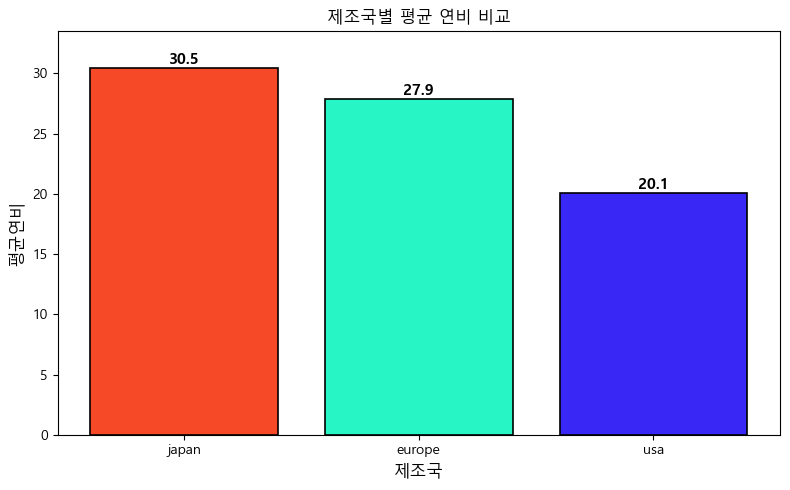

In [37]:
# 제조국(origin)별 평균 연비 mpg
origin_mpg = mpg.groupby('origin')['mpg'].mean().sort_values(ascending=False)

fig,ax = plt.subplots(figsize=(8,5))

bars = ax.bar(origin_mpg.index, origin_mpg.values,color=['#F54927','#27F5C5','#3827F5'],
       edgecolor = 'black', linewidth=1.2)


# 막대 위에 수치 표시
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height, 
            f'{height:.1f}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_xlabel('제조국',fontsize=12)
ax.set_ylabel('평균연비',fontsize=12)
ax.set_title('제조국별 평균 연비 비교')
ax.set_ylim(0, origin_mpg.max()*1.1)
plt.tight_layout()
plt.show()

# 인사이트: 일본(japan) 차량이 평균 30.5mpg로 가장 효율적 → 소형차 중심 전략

## 4. 산점도: 두 변수의 관계

**비즈니스 질문:** 차량 무게와 연비는 어떤 관계일까?

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

# 제조국별로 색상 구분


#  인사이트: 강한 음의 상관관계 확인 - 무게가 1000lbs 증가 시 연비 약 10mpg 감소
#  일본 차량군이 좌상단(가볍고 연비 좋음)에 집중 → 경량화 전략의 효과

## 5. 스타일 커스터마이징

**색상, 마커, 선 스타일 조합으로 가독성 향상**

In [ ]:
# 실린더 수별 연비 분포


# 다양한 마커와 선 스타일


#  인사이트: 실린더 수와 연비는 반비례 관계 - 8기통 차량은 4기통 대비 연비 50% 수준

---

## 핵심 요약

### 코드 패턴 (30%)
```python
fig, ax = plt.subplots(figsize=(width, height))
ax.plot() / ax.bar() / ax.scatter()
ax.set_xlabel() / ax.set_ylabel() / ax.set_title()
plt.tight_layout()
plt.show()
```

### 도출된 인사이트 (70%)
1. **시간 추세**: 1975년 이후 연비 30% 향상 → 규제 효과
2. **국가별 차이**: 일본 차량 연비 최고 → 소형차 전략
3. **물리적 제약**: 무게 증가 시 연비 선형 감소 → 경량화 필요
4. **엔진 설계**: 실린더 수 증가 시 연비 급격히 하락 → 다운사이징 트렌드

### 실무 적용
- 제품 기획: 경량 소형 모델 개발 우선순위 상향
- 마케팅: 일본 시장 벤치마킹 필요성
- R&D: 8기통 대체 기술 투자 검토